# Hackathon Digital Twin

This notebook talks to the hackathon microscope like a real instrument. Move the beam, acquire a camera image, then read the returned Tiled key.

Start the servers from the repo root before running the notebook:

```bash
uv run python startup_scripts/run_servers.py --yaml configs/hackathon.yaml
```

### Imports


In [1]:
import os
import json
import tango
import numpy as np
from pprint import pprint
import matplotlib.pyplot as plt
from tiled.client import from_uri
from pathlib import Path

%matplotlib ipympl

### Ping servers


In [2]:
DB_HOST = "localhost"
DB_PORT = 9094

os.environ["TANGO_HOST"] = f"{DB_HOST}:{DB_PORT}"

server_names = ['stage', 'scan', 'camera', 'data', 'instrument']

scan = tango.DeviceProxy("asyncroscopy/scan/default")
microscope = tango.DeviceProxy("asyncroscopy/instrument/default")
data = tango.DeviceProxy("asyncroscopy/data/default")

for proxy in [scan, microscope, data]:
    proxy.set_timeout_millis(120_000)
    proxy.ping()
    print(proxy.name(), proxy.state())

asyncroscopy/scan/default ON
asyncroscopy/instrument/default ON
asyncroscopy/data/default ON


### Set Tiled Client


In [3]:
config = json.loads(data.get_config())
config

{'host': '127.0.0.1',
 'port': 9091,
 'uri': 'http://127.0.0.1:9091',
 'save_path': '/Users/austin/Desktop/18167694/hackathon_data',
 'tiled_server': 'yes',
 'tiled_server_status': 'running; registered save path',
 'tiled_server_serving': '/Users/austin/Desktop/18167694/hackathon_data'}

In [4]:
client = from_uri(config.get("uri"))
print("Tiled keys:", list(client))

Tiled keys: ['camera_image_x467_y282.h5', 'camera_image_x493_y292.h5', 'camera_image_x467_y113.h5', 'camera_image_x493_y103.h5', 'camera_image_x460_y494.h5', 'camera_image_x494_y484.h5', 'camera_image_x399_y287.h5', 'camera_image_x175_y447.h5', 'camera_image_x181_y457.h5', 'camera_image_x218_y276.h5', 'camera_image_x399_y116.h5', 'camera_image_x370_y336.h5', 'camera_image_x384_y326.h5', 'camera_image_x007_y121.h5', 'camera_image_x419_y458.h5', 'camera_image_x205_y046.h5', 'camera_image_x172_y251.h5', 'camera_image_x186_y241.h5', 'camera_image_x123_y252.h5', 'camera_image_x254_y045.h5', 'camera_image_x056_y122.h5', 'camera_image_x321_y335.h5', 'camera_image_x249_y275.h5', 'camera_image_x124_y444.h5', 'camera_image_x431_y497.h5', 'camera_image_x358_y068.h5', 'camera_image_x436_y281.h5', 'camera_image_x345_y258.h5', 'camera_image_x436_y110.h5', 'camera_image_x028_y469.h5', 'camera_image_x230_y128.h5', 'camera_image_x312_y478.h5', 'camera_image_x267_y499.h5', 'camera_image_x293_y489.h5', '

## Acquire HAADF image

In [5]:
key = microscope.acquire_scanned_image(['HAADF'])
key

'overview_haadf.h5'

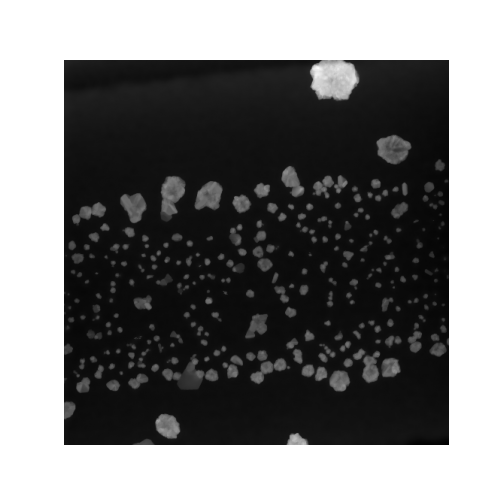

In [6]:
image = client[key]['image']['HAADF'].read()
metadata = dict(client[key]['image'].metadata)

plt.figure(figsize=(5, 5))
plt.imshow(image, cmap='gray')
plt.axis('off');

## Acquire a diffraction pattern

In [7]:
key = microscope.acquire_camera_image()
key

'camera_image_x256_y256.h5'

In [8]:
image = client[key]['image'].read()
metadata = dict(client[key]['image'].metadata)

image.shape, image.dtype, metadata

((192, 192),
 dtype('uint16'),
 {'acquisition_type': 'camera_image',
  'beam_index': '[256, 256]',
  'beam_position_fractional': '[0.5, 0.5]',
  'detector': 'BM-Ceta',
  'exposure_time': 0.001,
  'readout_area': 'Full',
  'requested_imsize': 1024,
  'source_dataset': 'source/camera_stack',
  'source_file': '/Users/austin/Desktop/18167694/hackathon_data/hackathon_camera_source.h5',
  'source_shape': '[512, 512, 192, 192]',
  'source_slice': '[256, 256, :, :]'})

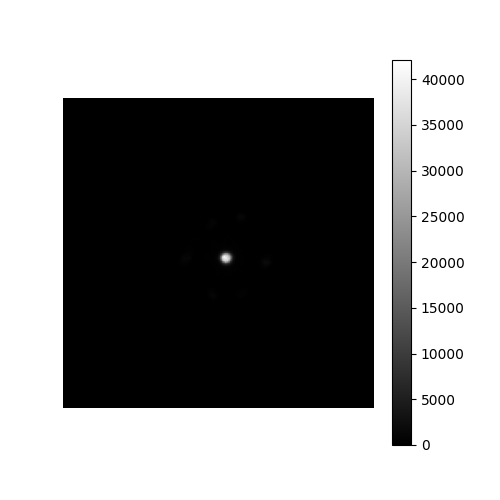

In [9]:
plt.figure(figsize=(5, 5))
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.colorbar()

## Target an acquisition

Beam positions are fractional coordinates in `[0, 1]`. The digital twin maps them onto the first two dimensions of the 4D-STEM source dataset.

In [17]:
microscope.place_beam([0.50, 0.50])
key = microscope.acquire_camera_image()


DevFailed: DevFailed[
    DevError[
        desc = Thread 10 is not able to acquire serialization monitor "asyncroscopy/data/default",  it is currently held by thread 9.
        origin = void Tango::TangoMonitor::get_monitor() at (/Users/runner/miniforge3/conda-bld/cpptango_1758200193404/work/src/include/tango/server/tango_monitor.h:177)
        reason = API_CommandTimedOut
        severity = ERR
    ],
    DevError[
        desc = Failed to execute command_inout on device asyncroscopy/data/default, command register_path
        origin = virtual DeviceData Tango::Connection::command_inout(const std::string &, const DeviceData &) at (/Users/runner/miniforge3/conda-bld/cpptango_1758200193404/work/src/client/devapi_base.cpp:2029)
        reason = API_CommandFailed
        severity = ERR
    ],
    DevError[
        desc = Cannot execute command
        origin = virtual CORBA::Any *PyCmd::execute(Tango::DeviceImpl *, const CORBA::Any &) at (/Users/gitlab/builds/tango-controls/pytango/ext/s

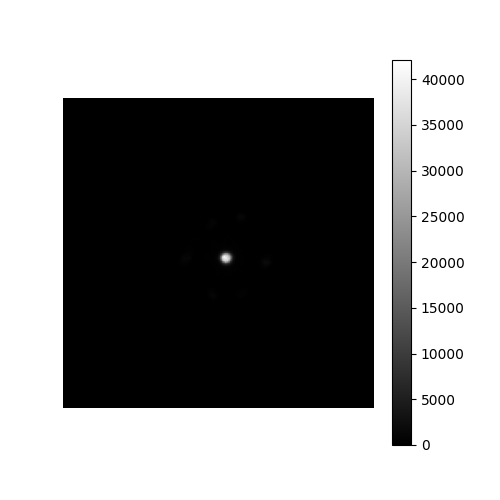

In [15]:
image = client[key]['image'].read()

plt.figure(figsize=(5, 5))
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.colorbar()

Try a few beam positions and compare the returned camera frames.

In [ ]:
positions = [(0.10, 0.10), (0.30, 0.70), (0.80, 0.40)]
fig, axes = plt.subplots(1, len(positions), figsize=(12, 4))

for ax, position in zip(axes, positions):
    microscope.place_beam(position)
    key = microscope.acquire_camera_image()
    image = client[key]['image'].read()
    beam_index = dict(client[key]['image'].metadata).get('beam_index')
    ax.imshow(image, cmap='gray')
    ax.set_title(f'{position}\n{beam_index}')
    ax.axis('off')

plt.tight_layout()